# Elastic net (Durbin–Willshaw) pour le TSP euclidien

Un lacet de $M$ nœuds $y_0,\dots,y_{M-1}$ est déposé au centre du nuage, puis relâché sous deux forces
antagonistes pendant qu'on baisse un paramètre d'échelle $K$ (recuit déterministe).

**Énergie**

$$E \;=\; -\alpha K \sum_{i=1}^{n} \log \sum_{j=0}^{M-1} e^{-\|x_i-y_j\|^2/2K^2}
\;+\; \beta \sum_{j} \|y_{j+1}-y_j\|^2$$

Le premier terme est un **soft-min** : quand $K\to 0$ il tend vers $\tfrac12\min_j\|x_i-y_j\|^2$.
C'est toute l'astuce — à $K$ grand chaque ville tire *tout* le lacet (paysage quasi convexe),
à $K$ petit elle ne voit plus que son nœud le plus proche. Le recuit sur $K$ **est** l'algorithme.

**Règle de mise à jour** (Durbin & Willshaw 1987)

$$w_{ij}=\frac{e^{-\|x_i-y_j\|^2/2K^2}}{\sum_k e^{-\|x_i-y_k\|^2/2K^2}},
\qquad
\Delta y_j=\underbrace{\alpha\sum_i w_{ij}(x_i-y_j)}_{\text{attraction}}
+\underbrace{\beta K\,(y_{j+1}-2y_j+y_{j-1})}_{\text{tension élastique}}$$

Trois détails qui font toute la différence entre « ça marche » et « ça diverge » :

- les poids sont normalisés **par ville** (somme sur $j$), pas par nœud — c'est ce qui empêche
  deux villes d'être capturées par le même nœud ;
- le $K$ devant le Laplacien : la raideur doit s'éteindre en même temps que la portée,
  sinon le lacet reste un cercle ;
- log-sum-exp stabilisé, sinon underflow total dès que $K$ descend.

**Plan** — recuit → extraction du tour → raffinement 2-opt / Or-opt → comparaisons.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import time

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. Le nuage

Points uniformes dans $[0,1]^2$. Tout est normalisé dans le carré unité : les valeurs
par défaut de $\alpha,\beta,K_0$ ci-dessous sont calibrées pour cette échelle.

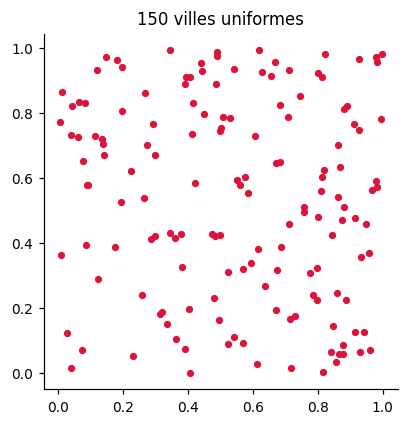

In [2]:
N_VILLES = 150
X = rng.random((N_VILLES, 2))

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(*X.T, s=14, c="crimson", zorder=3)
ax.set_aspect("equal"); ax.set_title(f"{N_VILLES} villes uniformes")
plt.show()

## 2. Le cœur du recuit

`sqdist` utilise l'identité $\|x-y\|^2=\|x\|^2-2x^\top y+\|y\|^2$ : un seul `matmul` au lieu
d'un tenseur $n\times M\times 2$, environ 3× plus rapide.

Le `np.maximum(..., 0)` corrige les valeurs légèrement négatives dues à l'annulation catastrophique
quand deux points coïncident presque.

In [3]:
def sqdist(A, B):
    """Matrice des distances au carré, |A| x |B|."""
    return np.maximum((A*A).sum(1)[:, None] - 2*A @ B.T + (B*B).sum(1)[None, :], 0.0)


def elastic_net(X, M=None, alpha=0.2, beta=2.0,
                K0=0.2, Kmin=0.01, decay=0.99, iters_per_K=25,
                r0=0.1, snapshots=(), verbose=True):
    """Recuit de Durbin-Willshaw. Renvoie (noeuds, historique, snapshots, n_iter)."""
    n = len(X)
    M = M or int(2.5 * n)                      # ~2.5 noeuds par ville

    # lacet initial : petit cercle au barycentre
    c = X.mean(0)
    th = np.linspace(0, 2*np.pi, M, endpoint=False)
    Y = c + r0 * np.c_[np.cos(th), np.sin(th)]

    hist, snaps, K, it = [], {}, K0, 0
    t0 = time.time()
    while K > Kmin:
        for _ in range(iters_per_K):
            # --- poids softmax, normalises PAR VILLE, log-sum-exp stabilise
            L = -sqdist(X, Y) / (2*K*K)        # n x M
            L -= L.max(1, keepdims=True)       # <- indispensable
            W = np.exp(L)
            W /= W.sum(1, keepdims=True)

            # --- attraction : alpha * sum_i w_ij (x_i - y_j)
            attract = alpha * (W.T @ X - W.sum(0)[:, None] * Y)
            # --- tension : beta * K * Laplacien circulant
            elast = beta * K * (np.roll(Y, -1, 0) - 2*Y + np.roll(Y, 1, 0))

            Y += attract + elast
            it += 1

        perim = np.linalg.norm(np.roll(Y, -1, 0) - Y, axis=1).sum()
        # distorsion : distance moyenne ville -> lacet
        dist = np.sqrt(sqdist(X, Y).min(1)).mean()
        hist.append((K, perim, dist))

        for s in snapshots:
            if s not in snaps and K <= s:
                snaps[s] = Y.copy()
        K *= decay

    if verbose:
        print(f"{it} iterations, M={M} noeuds, {time.time()-t0:.1f} s")
    return Y, np.array(hist), snaps, it

In [4]:
SNAPS = (0.20, 0.12, 0.07, 0.04, 0.02, 0.011)
Y, hist, snaps, n_it = elastic_net(X, snapshots=SNAPS)

7475 iterations, M=375 noeuds, 5.5 s


## 3. Le recuit en images

On voit le cercle se déformer globalement tant que $K$ est grand, puis se plaquer sur les villes
une par une quand $K$ descend.

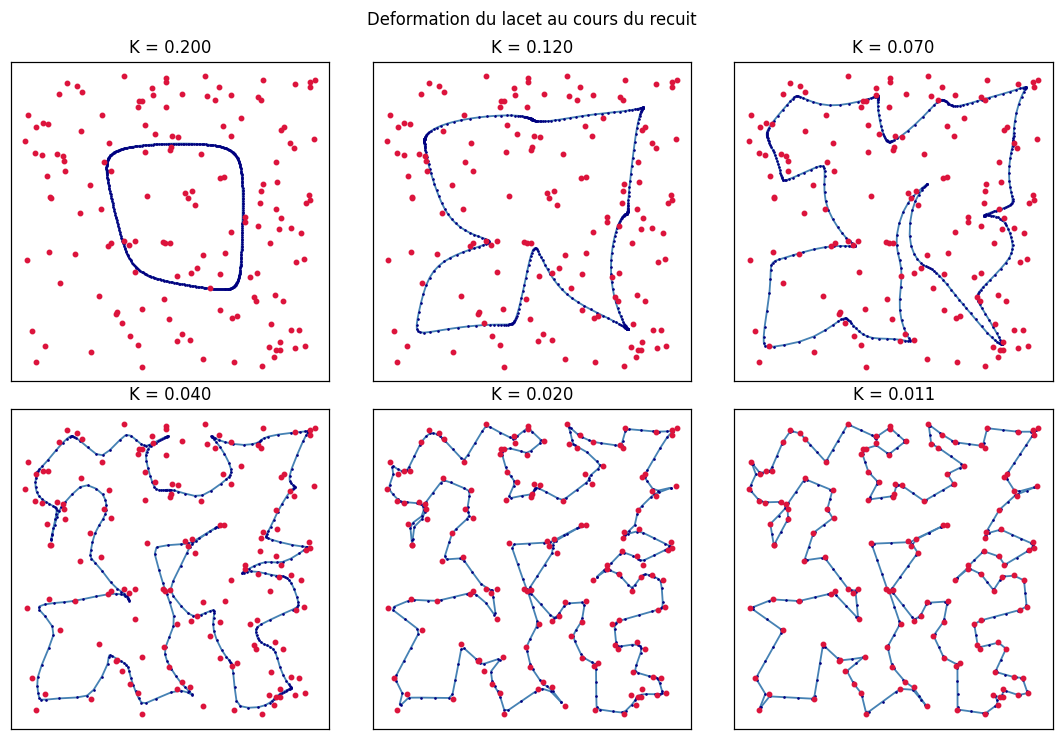

In [5]:
def plot_net(ax, X, Y, title="", show_pts=True):
    seg = np.stack([Y, np.roll(Y, -1, 0)], axis=1)
    ax.add_collection(LineCollection(seg, colors="steelblue", lw=1.2, zorder=2))
    ax.plot(*Y.T, ".", ms=1.5, c="navy", zorder=3)
    if show_pts:
        ax.scatter(*X.T, s=8, c="crimson", zorder=4)
    ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True)
    ax.autoscale_view()

ks = sorted(snaps, reverse=True)
fig, axes = plt.subplots(2, 3, figsize=(10, 6.8))
for ax, k in zip(axes.ravel(), ks):
    plot_net(ax, X, snaps[k], f"K = {k:.3f}")
fig.suptitle("Deformation du lacet au cours du recuit", y=0.98)
plt.tight_layout(); plt.show()

## 4. Extraction du tour

Chaque ville est affectée à son nœud le plus proche, puis on trie par indice de nœud.
Deux villes peuvent tomber sur le même nœud : on départage par la projection sur la tangente
locale $y_{j+1}-y_{j-1}$, ce qui respecte le sens de parcours.

In [6]:
def extract_tour(X, Y):
    """Villes -> permutation, via le noeud le plus proche + tangente pour les ex aequo."""
    d2 = sqdist(X, Y)
    j = d2.argmin(1)
    tang = np.roll(Y, -1, 0) - np.roll(Y, 1, 0)
    t = tang[j]
    t /= np.maximum(np.linalg.norm(t, axis=1, keepdims=True), 1e-12)
    off = ((X - Y[j]) * t).sum(1)
    return np.lexsort((off, j))          # tri par (noeud, offset)


tour_raw = extract_tour(X, Y)
assert len(set(tour_raw.tolist())) == len(X), "permutation invalide"
print("tour brut extrait :", tour_raw[:12], "...")

tour brut extrait : [115  57  66   8  84  61  97  99 112 122  68 142] ...


## 5. Raffinement local

L'elastic net donne un bon tour mais pas localement optimal. **2-opt** supprime les croisements,
**Or-opt** déplace des segments de 1 à 3 villes ailleurs dans le tour (éventuellement retournés) —
c'est lui qui rattrape les villes « oubliées » sur le côté, ce que 2-opt ne sait pas faire.

Les deux sont vectorisés : pour chaque position on évalue *tous* les partenaires d'un coup.

In [7]:
def dmat(X):
    return np.sqrt(sqdist(X, X))

def tour_len(tour, D):
    return D[tour, np.roll(tour, -1)].sum()


def two_opt(tour, D, max_passes=200):
    """Suppression des croisements : on inverse un segment."""
    tour = np.asarray(tour).copy(); n = len(tour)
    for _ in range(max_passes):
        improved = False
        for i in range(n - 1):
            a, b = tour[i], tour[i+1]
            js = np.arange(i+2, n)
            if js.size == 0:
                continue
            c, d = tour[js], tour[(js+1) % n]
            delta = D[a, c] + D[b, d] - D[a, b] - D[c, d]
            k = delta.argmin()
            if delta[k] < -1e-10:
                tour[i+1:js[k]+1] = tour[i+1:js[k]+1][::-1]
                improved = True
        if not improved:
            break
    return tour


def or_opt(tour, D, max_passes=50, seg_lens=(1, 2, 3)):
    """Deplacement d'un segment court ailleurs dans le tour, dans un sens ou l'autre."""
    tour = np.asarray(tour).copy(); n = len(tour)
    for _ in range(max_passes):
        improved = False
        for s in seg_lens:
            for i in range(n):
                idx = np.arange(i, i+s) % n
                seg = tour[idx]
                prev, nxt = tour[(i-1) % n], tour[(i+s) % n]
                rest = np.delete(tour, idx)
                gain = D[prev, seg[0]] + D[seg[-1], nxt] - D[prev, nxt]   # economie au retrait
                u, v = rest, np.roll(rest, -1)
                base = D[u, v]
                df = D[u, seg[0]] + D[seg[-1], v] - base - gain           # cout net, sens direct
                dr = D[u, seg[-1]] + D[seg[0], v] - base - gain           # ... et retourne
                kf, kr = df.argmin(), dr.argmin()
                if min(df[kf], dr[kr]) < -1e-10:
                    k, sg = (kf, seg) if df[kf] <= dr[kr] else (kr, seg[::-1])
                    tour = np.concatenate([rest[:k+1], sg, rest[k+1:]])
                    improved = True
        if not improved:
            break
    return tour


def polish(tour, D, rounds=3):
    for _ in range(rounds):
        before = tour_len(tour, D)
        tour = or_opt(two_opt(tour, D), D)
        if tour_len(tour, D) > before - 1e-10:
            break
    return two_opt(tour, D)

In [8]:
D = dmat(X)
t0 = time.time()
tour = polish(tour_raw, D)
print(f"raffinement : {time.time()-t0:.2f} s")
print(f"brut      {tour_len(tour_raw, D):8.4f}")
print(f"raffine   {tour_len(tour, D):8.4f}")

raffinement : 0.06 s
brut       10.2408
raffine     9.7532


## 6. Comparaisons

Deux références classiques :

- **tri angulaire** (balayage radial autour du barycentre) — le tour qu'on obtiendrait en fixant
  l'assignation ville→paramètre a priori. Asymptotiquement $\Theta(n)$ contre $\Theta(\sqrt n)$
  pour l'optimum, donc mauvais par construction ;
- **plus proche voisin**, glouton.

La référence d'échelle est la constante de Beardwood–Halton–Hammersley :
$L^\star \sim 0{,}7124\sqrt{nA}$ pour $n$ points uniformes sur une aire $A$ (asymptotique,
donc les ratios affichés sont indicatifs à cette taille).

In [9]:
def sweep_tour(X):
    d = X - X.mean(0)
    return np.argsort(np.arctan2(d[:, 1], d[:, 0]))

def nn_tour(D):
    n = len(D); unvisited = np.ones(n, bool); unvisited[0] = False
    t = [0]
    for _ in range(n-1):
        d = np.where(unvisited, D[t[-1]], np.inf)
        t.append(int(d.argmin())); unvisited[t[-1]] = False
    return np.array(t)


bhh = 0.7124 * np.sqrt(len(X))
rows = [
    ("tri angulaire",           sweep_tour(X)),
    ("plus proche voisin",      nn_tour(D)),
    ("PPV + 2-opt + Or-opt",    polish(nn_tour(D), D)),
    ("elastic net (brut)",      tour_raw),
    ("elastic net + raffinement", tour),
]
print(f"{'methode':<28}{'longueur':>10}{'/BHH':>8}")
print("-" * 46)
for name, t in rows:
    L = tour_len(t, D)
    print(f"{name:<28}{L:>10.4f}{L/bhh:>8.3f}")

methode                       longueur    /BHH
----------------------------------------------
tri angulaire                  22.5511   2.585
plus proche voisin             11.2011   1.284
PPV + 2-opt + Or-opt            9.7947   1.123
elastic net (brut)             10.2408   1.174
elastic net + raffinement       9.7532   1.118


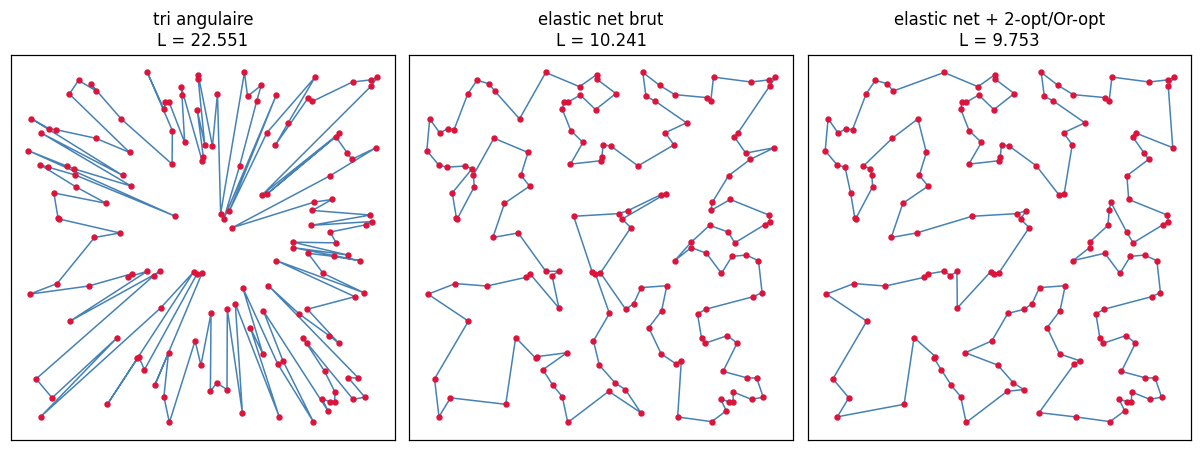

In [10]:
def plot_tour(ax, X, tour, title):
    p = X[np.r_[tour, tour[0]]]
    ax.plot(*p.T, "-", lw=1.0, c="steelblue", zorder=2)
    ax.scatter(*X.T, s=10, c="crimson", zorder=3)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True)
    ax.set_title(f"{title}\nL = {tour_len(tour, D):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
plot_tour(axes[0], X, sweep_tour(X), "tri angulaire")
plot_tour(axes[1], X, tour_raw, "elastic net brut")
plot_tour(axes[2], X, tour, "elastic net + 2-opt/Or-opt")
plt.tight_layout(); plt.show()

## 7. Diagnostic du recuit

Le périmètre du lacet et la distorsion (distance moyenne ville → lacet) en fonction de $K$.
La distorsion doit tomber vers 0 : si elle plafonne, c'est que des villes sont restées orphelines
et qu'il faut allonger le recuit ou augmenter $\alpha$.

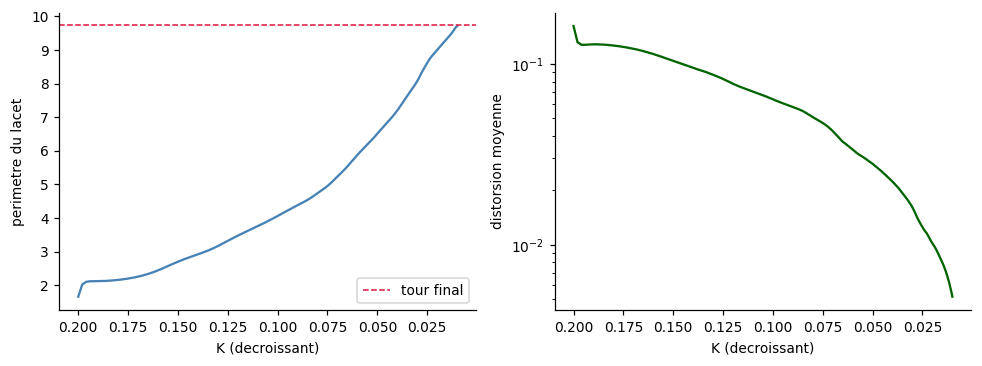

distorsion finale : 5.14e-03  (doit etre << espacement typique 0.082)


In [11]:
K_, perim_, dist_ = hist.T
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(K_, perim_, c="steelblue"); ax[0].invert_xaxis()
ax[0].axhline(tour_len(tour, D), ls="--", c="crimson", lw=1, label="tour final")
ax[0].set_xlabel("K (decroissant)"); ax[0].set_ylabel("perimetre du lacet"); ax[0].legend()
ax[1].plot(K_, dist_, c="darkgreen"); ax[1].invert_xaxis(); ax[1].set_yscale("log")
ax[1].set_xlabel("K (decroissant)"); ax[1].set_ylabel("distorsion moyenne")
plt.tight_layout(); plt.show()

print(f"distorsion finale : {dist_[-1]:.2e}  (doit etre << espacement typique {1/np.sqrt(len(X)):.3f})")

## 8. Bonus — pas élastique exact en Fourier

Le Laplacien discret $y_{j+1}-2y_j+y_{j-1}$ est **circulant**, donc diagonalisé par la FFT :
son symbole est $-4\sin^2(\pi k/M)$. Le terme explicite impose $\Delta t \lesssim 1/(\beta K M^2)$ —
c'est lui qui limite le pas de temps.

En **splitting semi-implicite** (attraction explicite, puis pas exact sur l'élastique) :

$$\hat y_k \;\leftarrow\; \frac{\hat y_k}{1 + 4\,\beta K\,\Delta t\,\sin^2(\pi k/M)}$$

deux FFT, inconditionnellement stable, donc on peut prendre $\Delta t$ bien plus grand
et diviser le nombre d'itérations par 5 à quantité de recuit égale.

In [12]:
def elastic_net_fft(X, M=None, alpha=0.2, beta=2.0, K0=0.2, Kmin=0.01,
                    decay=0.99, iters_per_K=5, dt=5.0, r0=0.1, verbose=True):
    n = len(X); M = M or int(2.5*n)
    c = X.mean(0); th = np.linspace(0, 2*np.pi, M, endpoint=False)
    Y = c + r0*np.c_[np.cos(th), np.sin(th)]

    k = np.fft.fftfreq(M, 1/M)
    lam = 4*np.sin(np.pi*k/M)**2            # symbole du -Laplacien circulant

    K, it = K0, 0; t0 = time.time()
    while K > Kmin:
        for _ in range(iters_per_K):
            L = -sqdist(X, Y)/(2*K*K); L -= L.max(1, keepdims=True)
            W = np.exp(L); W /= W.sum(1, keepdims=True)
            Y = Y + dt*alpha*(W.T @ X - W.sum(0)[:, None]*Y)        # explicite
            Y = np.real(np.fft.ifft(np.fft.fft(Y, axis=0)/(1 + beta*K*dt*lam)[:, None], axis=0))
            it += 1
        K *= decay
    if verbose:
        print(f"{it} iterations, {time.time()-t0:.1f} s")
    return Y, it


t0 = time.time(); Yf, itf = elastic_net_fft(X)
tour_f = polish(extract_tour(X, Yf), D)
print(f"explicite : {n_it:5d} it  ->  L = {tour_len(tour, D):.4f}")
print(f"Fourier   : {itf:5d} it  ->  L = {tour_len(tour_f, D):.4f}")

1495 iterations, 1.1 s
explicite :  7475 it  ->  L = 9.7532
Fourier   :  1495 it  ->  L = 9.7532


## 9. Réglages

| paramètre | défaut | effet |
|---|---|---|
| `M` | $2.5n$ | trop peu de nœuds → villes fusionnées ; trop → lent et flottant |
| `alpha` | 0.2 | force d'attraction ; augmenter si des villes restent orphelines |
| `beta` | 2.0 | raideur ; trop grand → le lacet reste circulaire, trop petit → il se noue |
| `K0` | 0.2 | doit couvrir le nuage (~ son diamètre / 5) |
| `Kmin` | 0.01 | $\ll$ espacement typique $1/\sqrt n$ |
| `decay` | 0.99 | plus lent = meilleur ; 0.97 divise le temps par 4 pour ~1 % de longueur |

**Pistes**

- **Initialisation** par tri angulaire plutôt que par un cercle : $O(n\log n)$, gratuit, part un peu mieux.
- **Troncature du voisinage** : à $K$ petit, seuls les nœuds à distance $\lesssim 3K$ comptent.
  Un k-d tree (`scipy.spatial.cKDTree`) ramène le coût de $O(nM)$ à $O(n\log M)$ par itération —
  indispensable au-delà de ~2000 villes.
- **Or-3-opt / Lin–Kernighan** derrière le raffinement si on vise le dernier pour cent.
- **Plusieurs recuits** avec des germes différents, on garde le meilleur : l'elastic net reste
  sensible aux minima locaux malgré le recuit.